Downloading all necessary modules

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
%matplotlib inline
import warnings
warnings.filterwarnings('ignore',  module = "matplotlib\..*" )

Opening the csv file and cleaning the data

In [57]:
df = pd.read_csv(r"C:\Users\aser\OneDrive\Рабочий стол\DATASETS\Statistics\personality_and_posture.csv")
df.info()
df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   S No            97 non-null     int64  
 1   AGE             97 non-null     int64  
 2   HEIGHT          97 non-null     int64  
 3   WEIGHT          97 non-null     int64  
 4   SEX             97 non-null     object 
 5   ACTIVITY LEVEL  97 non-null     object 
 6   PAIN 1          97 non-null     float64
 7   PAIN 2          97 non-null     float64
 8   PAIN 3          97 non-null     float64
 9   PAIN 4          97 non-null     float64
 10  MBTI            97 non-null     object 
 11  E               97 non-null     int64  
 12  I               97 non-null     int64  
 13  S               97 non-null     int64  
 14  N               97 non-null     int64  
 15  T               97 non-null     int64  
 16  F               97 non-null     int64  
 17  J               97 non-null     int64

,S No,AGE,HEIGHT,WEIGHT,SEX,ACTIVITY LEVEL,PAIN 1,PAIN 2,PAIN 3,PAIN 4,MBTI,E,I,S,N,T,F,J,P,POSTURE
0,1,53,62,125,Female,Low,0.0,0.0,0.0,0.0,ESFJ,18,3,17,9,9,13,18,4,A
1,2,52,69,157,Male,High,7.0,8.0,5.0,3.0,ISTJ,6,15,14,12,21,3,13,9,B
2,3,30,69,200,Male,High,0.0,0.0,0.0,0.0,ESTJ,15,6,16,10,15,9,12,10,A
3,4,51,66,175,Male,Moderate,9.5,9.5,9.5,1.5,ISTJ,6,15,21,5,13,11,19,3,D
4,5,45,63,199,Female,Moderate,4.0,5.0,2.0,2.0,ENFJ,14,7,20,6,9,15,16,6,A
5,6,68,74,182,Male,Low,0.0,2.5,1.5,0.0,ISFP,4,17,17,9,11,13,4,18,D
6,7,62,68,263,Male,Low,7.0,10.0,10.0,10.0,ISTP,7,14,20,6,14,10,9,13,B
7,8,65,61,143,Female,Low,0.0,9.0,5.0,10.0,ESTJ,17,4,17,9,19,5,17,5,D
8,9,66,67,180,Male,Low,0.5,3.5,0.5,9.5,ESFJ,19,2,18,8,11,13,13,9,C
9,10,58,69,165,Male,Low,0.0,7.5,7.0,3.0,INFJ,5,16,13,13,11,13,17,5,D


The first column is perfect for the index 

In [58]:
df.set_index('S No', inplace=True)

Need to rename certain columns to make them more informative 

In [59]:
df.rename(columns={'PAIN 1':'Pain Neck', 'PAIN 2':'Pain Chest', 'PAIN 3':'Pain LBack','PAIN 4':'Pain Sacrum'}, inplace=True) 
df.rename(columns={'E':'Extraversion', 'I':'Introversion', 'S':'Sensing','N':'Intuition',
                   'T':'Thinking', 'F':'Feeling', 'J':'Judging','P':'Perceiving'}, inplace=True) 
df.columns = df.columns.str.title()

The values below also have to be changed for further analysis 

In [60]:
df.replace({'Posture' : {'A':3, 'B':2, 'C':1, 'D':0}}, inplace=True) # 3 is the best posture, 0 is the worst.
df.replace({'Activity Level' : {'High':2, 'Moderate':1, 'Low':0}}, inplace=True) # Self-explanotory 

Setting colors for further visualizations  

In [61]:
colors = ['#E68688', '#F1D078', '#AFD5C1', '#8FCCEC', '#EEAF9D', '#C4B2D6', '#A0A0A0'] 
colors_sex = ['#e1c5dd', '#6cb8f4']

Let's see if there is a sex bias. 

<Axes: xlabel='Sex', ylabel='count'>

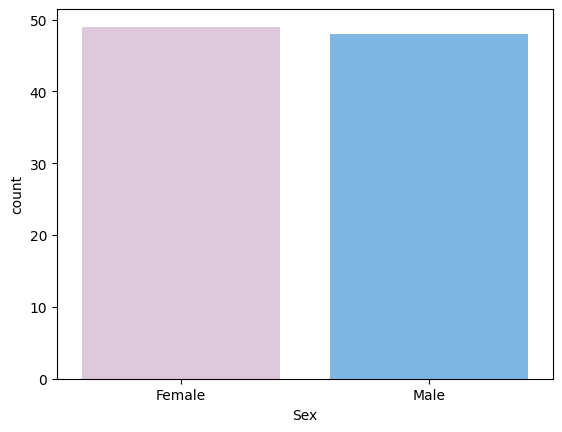

In [62]:
sns.countplot(x = df['Sex'], palette=colors_sex) 

Nope. Let's check age. 

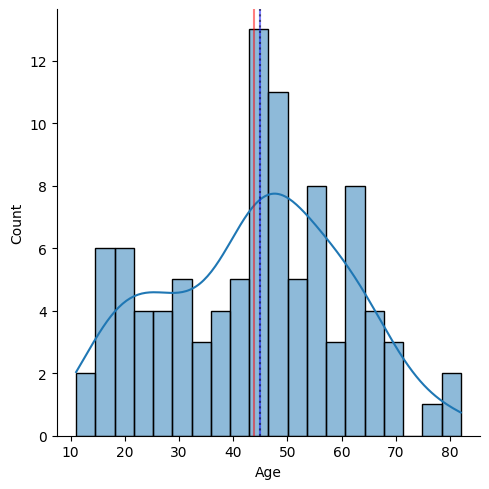

In [63]:
sns.displot(data= df, x = df['Age'], kde=True, bins=20)
plt.axvline(df['Age'].mode().item(), color='blue', alpha=0.5, linestyle='-')
plt.axvline(df['Age'].mean(), color='red', alpha=0.5)
plt.axvline(df['Age'].quantile(0.5), color='black', alpha=0.5, linestyle='dotted')

Counting how many introverts and extroverts we have and visualizing the quality of their posture (3 is the best)

Text(0.5, 1.0, 'Introverts')

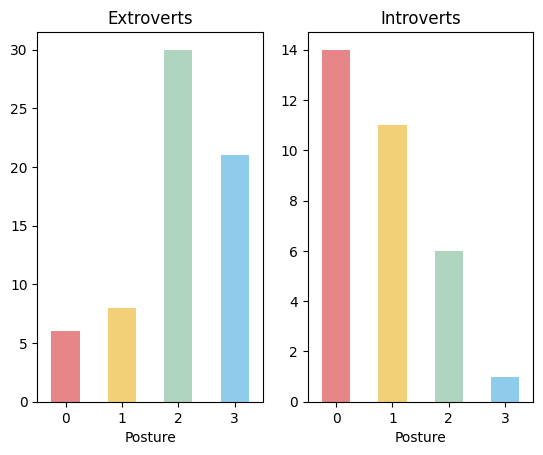

In [64]:
extroverts = df[df["Extraversion"] > df["Introversion"]]
introverts = df[df["Introversion"] >= df["Extraversion"]]

fig, ax = plt.subplots(1,2)
extroverts['Posture'].value_counts().sort_index().plot(kind='bar', rot=0, ax=ax[0], color=colors)
introverts['Posture'].value_counts().sort_index().plot(kind='bar', rot=0, ax=ax[1], color=colors)
ax[0].set_title('Extroverts')
ax[1].set_title('Introverts')

Apparently, introverts tend to have worse posture compared with extroverts, so there is a high chance that a
relationship between personality and posture exists. Let's make sure that it's not due to their activity level.


Text(0.5, 1.0, 'Introverts')

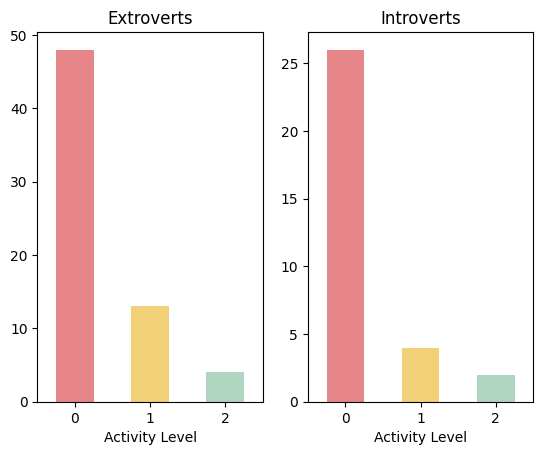

In [65]:
fig2, ax = plt.subplots(1,2)
extroverts['Activity Level'].value_counts().sort_index().plot(kind='bar', ax=ax[0], color=colors, rot=0)
introverts['Activity Level'].value_counts().sort_index().plot(kind='bar', ax=ax[1], color=colors, rot=0) 
ax[0].set_title('Extroverts')
ax[1].set_title('Introverts')

Both extraverts and introverts have approximately the same distribution by activity level, so there must be something else. Just in case, let's check if sex, height,  and weight have something to do with it. 

Text(0.5, 1.0, 'Male')

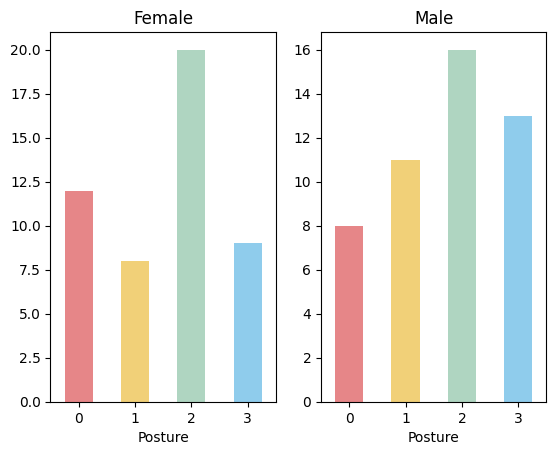

In [66]:
fig, ax = plt.subplots(1,2)
df[df['Sex'] == 'Female'].groupby('Posture')['Posture'].count().plot(kind='bar', color=colors, ax=ax[0], rot=0)
df[df['Sex'] == 'Male'].groupby('Posture')['Posture'].count().plot(kind='bar', color=colors, ax=ax[1], rot=0)
ax[0].set_title('Female')
ax[1].set_title('Male')


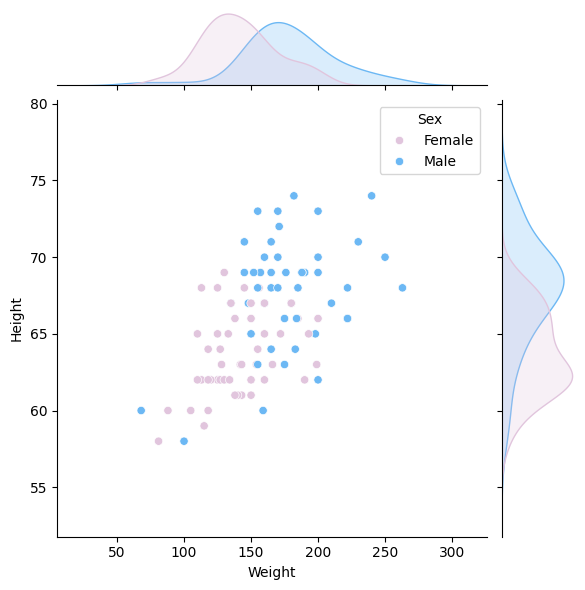

In [67]:
sns.jointplot(data = df, x = 'Weight', y = 'Height',  hue  = 'Sex', palette=colors_sex)

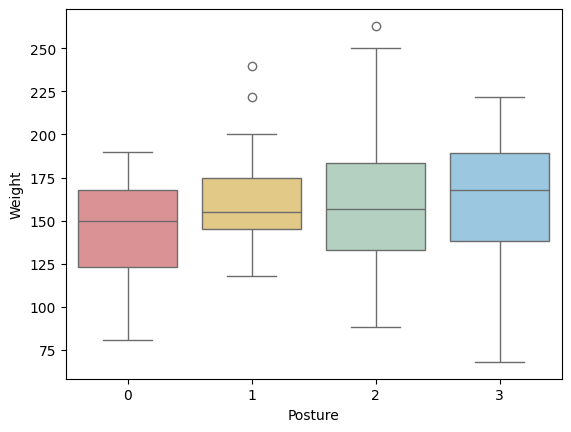

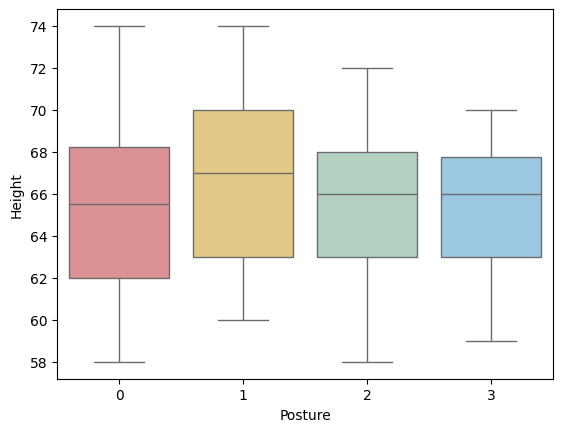

In [68]:
sns.boxplot(x = df['Posture'], y = df['Weight'], palette=colors) 
plt.show()
sns.boxplot(x = df['Posture'], y = df['Height'], palette=colors) 
plt.show()

It does seem like the sex of an individual matters. The significance of weight and height is difficult to determine; for this, we'll build a correlation heatmap.

<Axes: >

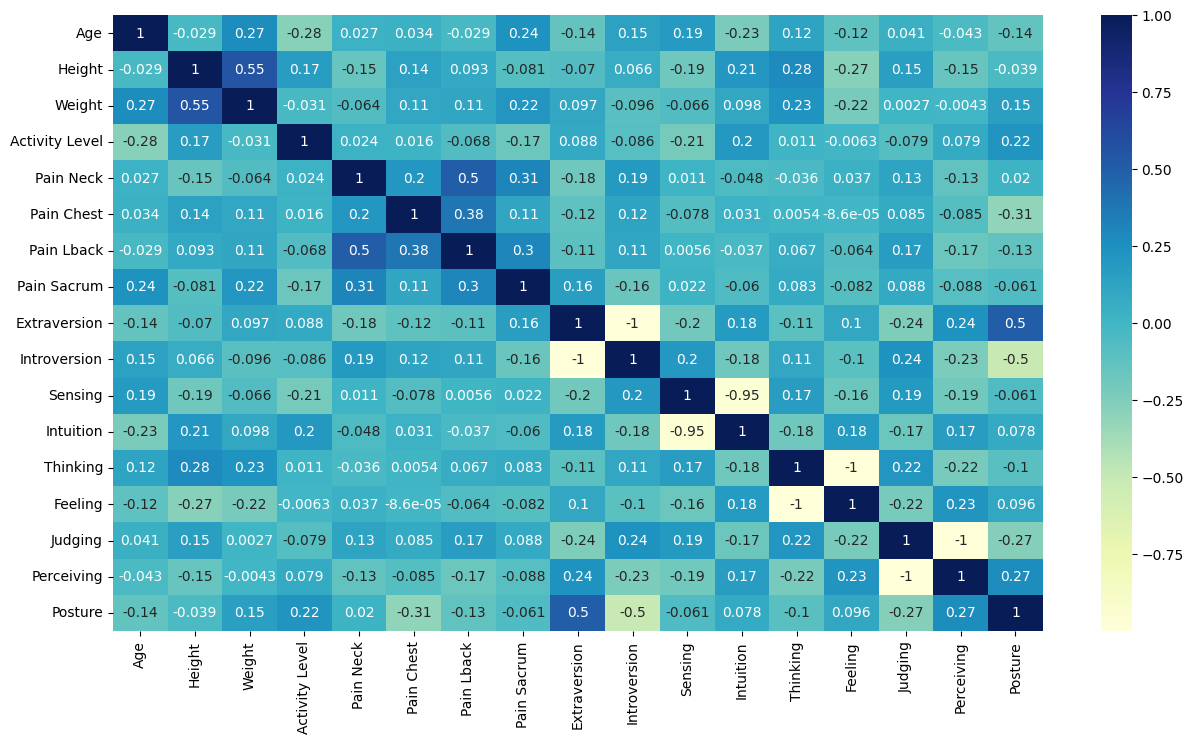

In [69]:
plt.figure(figsize=(15,8))
sns.heatmap(df.select_dtypes(include = np.number).corr(), annot=True, cmap='YlGnBu')

Extroversion and introversion appear to be the most significant factors for predicting posture, while height and neck pain are the least.

Transfroming Data for our predictive model.

In [70]:
df['Sex'] = df['Sex'].astype('category')
df.dtypes
df['Sex'] = df['Sex'].cat.codes
df['Mbti'] = df['Mbti'].astype(str)
df = pd.get_dummies(data=df, columns=["Mbti"], dtype=float)

MODEL TRAINING 

In [72]:
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns = 'Posture'), df['Posture'], 
                                               test_size=0.33, random_state=42)
lr = LogisticRegression()
lr.fit(x_train, y_train)
print("Logistig regression accuracy score", lr.score(x_train, y_train))


Logistig regression accuracy score 0.703125


In [73]:
rfr=RandomForestRegressor()
rfr.fit(x_train,y_train)
rfr.score(x_train,y_train)
print("RandomForestRegressor accuracy score", rfr.score(x_train, y_train))

RandomForestRegressor accuracy score 0.9233962165688193
